# AOA Generated Files Analysis

This notebook reviews what `notebooks/AOA_data.ipynb` does, compares the generated datasets, and proposes candidate training features based on the exported AoA files.

这个 notebook 用来梳理 `notebooks/AOA_data.ipynb` 的处理流程，对它导出的数据集做比较，并基于这些 AoA 文件提出适合训练的候选特征。


## 1. What `AOA_data.ipynb` does

`AOA_data.ipynb` builds a cleaned Age of Acquisition dataset from `data/raw/AoA_51715_words.xlsx`.

`AOA_data.ipynb` 的作用是从 `data/raw/AoA_51715_words.xlsx` 构建一个清洗后的 Age of Acquisition 数据集。

Main steps:
1. Read the raw AoA word list.
2. Drop rows without `Word` and remove duplicate words.
3. Cast the main lexical columns to numeric.
4. Build `Perc_known_final` using `Perc_known` first and `Perc_known_lem` as fallback.
5. Keep only rows with `Perc_known_final >= 0.8`.
6. Build `AoA_final` using this priority: `AoA_Kup -> AoA_Kup_lem -> AoA_Bird_lem -> AoA_Bristol_lem -> AoA_Cort_lem -> AoA_Schock`.
7. Convert `AoA_final` into three labels: `below_6`, `age_6_8`, `age_8_plus`.
8. Export multiple refined datasets with different frequency thresholds.

主要步骤如下：
1. 读取原始 AoA 词表。
2. 删除没有 `Word` 的记录，并对单词去重。
3. 将主要词汇列转换成数值类型。
4. 用 `Perc_known` 优先、`Perc_known_lem` 兜底，构造 `Perc_known_final`。
5. 只保留 `Perc_known_final >= 0.8` 的样本。
6. 按照 `AoA_Kup -> AoA_Kup_lem -> AoA_Bird_lem -> AoA_Bristol_lem -> AoA_Cort_lem -> AoA_Schock` 的优先级构造 `AoA_final`。
7. 将 `AoA_final` 转成三个年龄标签：`below_6`、`age_6_8`、`age_8_plus`。
8. 根据不同词频阈值导出多个 refined dataset。


In [29]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

ROOT = Path.cwd()
if ROOT.name == 'iteration2':
    ROOT = ROOT.parent.parent

ROOT


PosixPath('/Users/datong/Documents/5120/Nurodiversity inclusive design/data/TP10_DS')

In [30]:
raw_path = ROOT / 'data/raw/AoA_51715_words.xlsx'
v2_path = ROOT / 'data/processed/AoA_refined_dataset_v2.xlsx'
v3_freq2_path = ROOT / 'data/processed/AoA_refined_dataset_v3_freq2.xlsx'
v3_freq5_path = ROOT / 'data/processed/AoA_refined_dataset_v3_freq5.xlsx'

raw_df = pd.read_excel(raw_path)
v2_df = pd.read_excel(v2_path)
v3_freq2_df = pd.read_excel(v3_freq2_path)
v3_freq5_df = pd.read_excel(v3_freq5_path)

print('raw:', raw_df.shape)
print('v2:', v2_df.shape)
print('v3_freq2:', v3_freq2_df.shape)
print('v3_freq5:', v3_freq5_df.shape)


raw: (51715, 16)
v2: (14471, 20)
v3_freq2: (9997, 20)
v3_freq5: (5889, 20)


## 2. Compare generated files

The notebook exports three main training candidates:
- `v2`: `Freq_pm >= 1`
- `v3_freq2`: `Freq_pm >= 2`
- `v3_freq5`: `Freq_pm >= 5`

A useful training set should keep enough rows while not being too skewed toward only very common early-acquired words.

这个 notebook 主要导出了三个训练候选版本：
- `v2`: `Freq_pm >= 1`
- `v3_freq2`: `Freq_pm >= 2`
- `v3_freq5`: `Freq_pm >= 5`

一个适合训练的数据集应该既保留足够多的样本，也不要过度偏向非常常见、非常早学会的词。


In [31]:
datasets = {
    'v2': v2_df,
    'v3_freq2': v3_freq2_df,
    'v3_freq5': v3_freq5_df,
}

summary_rows = []
for name, df in datasets.items():
    age_pct = (df['Age_Group'].value_counts(normalize=True) * 100).to_dict()
    summary_rows.append({
        'dataset': name,
        'rows': len(df),
        'mean_freq_pm': df['Freq_pm'].mean(),
        'median_freq_pm': df['Freq_pm'].median(),
        'mean_aoa_final': df['AoA_final'].mean(),
        'below_6_pct': age_pct.get('below_6', 0),
        'age_6_8_pct': age_pct.get('age_6_8', 0),
        'age_8_plus_pct': age_pct.get('age_8_plus', 0),
    })

summary_df = pd.DataFrame(summary_rows).round(2)
display(summary_df)


,dataset,rows,mean_freq_pm,median_freq_pm,mean_aoa_final,below_6_pct,age_6_8_pct,age_8_plus_pct
0,v2,14471,60.06,3.53,8.08,24.18,24.82,51.00
1,v3_freq2,9997,86.31,6.53,7.53,30.36,27.18,42.46
2,v3_freq5,5889,144.32,14.25,6.85,39.46,29.46,31.07


### Observation

- `v2` keeps the most rows, but it leans more heavily toward `age_8_plus`.
- `v3_freq5` keeps only the most frequent words, so it shifts strongly toward `below_6`.
- `v3_freq2` is the best compromise here: it still has nearly 10k rows and the class split is more balanced.

For the rest of the analysis, we use `v3_freq2` as the main candidate for training.

观察结论：
- `v2` 保留的样本最多，但更偏向 `age_8_plus`。
- `v3_freq5` 只保留更高频的词，因此会明显偏向 `below_6`。
- `v3_freq2` 在这里是比较合理的折中：样本量接近 1 万，而且类别分布更平衡。

因此后面的分析主要使用 `v3_freq2` 作为训练候选数据集。


In [32]:
df = v3_freq2_df.copy()

# Data quality cleanup: some rows in Dom_PoS_SUBTLEX contain numeric values copied from Freq_pm.
numeric_pos_mask = df['Dom_PoS_SUBTLEX'].apply(lambda x: isinstance(x, (int, float)) and not pd.isna(x))
df.loc[numeric_pos_mask, 'Dom_PoS_SUBTLEX'] = 'Unknown'
df['Dom_PoS_SUBTLEX'] = df['Dom_PoS_SUBTLEX'].fillna('Unknown').astype(str)
df['AoA_source'] = df['AoA_source'].fillna('Unknown').astype(str)

# Derived features for training analysis.
df['log_freq_pm'] = np.log1p(df['Freq_pm'])
df['is_lemma_match'] = (
    df['Word'].astype(str).str.lower() == df['Lemma_highest_PoS'].astype(str).str.lower()
).astype(int)
df['has_alt_spelling'] = df['Alternative.spelling'].notna().astype(int)
df['word_len_minus_phon'] = df['Nletters'] - df['Nphon']
df['phon_per_syll'] = df['Nphon'] / df['Nsyll'].replace(0, np.nan)
df['letters_per_syll'] = df['Nletters'] / df['Nsyll'].replace(0, np.nan)
df['letters_x_syll'] = df['Nletters'] * df['Nsyll']
df['phon_x_syll'] = df['Nphon'] * df['Nsyll']

print('Rows in working dataset:', len(df))
print('Rows with repaired POS values:', int(numeric_pos_mask.sum()))


Rows in working dataset: 9997
Rows with repaired POS values: 23


In [33]:
group_profile = df.groupby('Age_Group')[['Freq_pm', 'log_freq_pm', 'Nletters', 'Nphon', 'Nsyll', 'Perc_known_final']].mean().round(3)
display(group_profile)


,Freq_pm,log_freq_pm,Nletters,Nphon,Nsyll,Perc_known_final
Age_Group,,,,,,
age_6_8,29.554,2.420,6.521,5.411,1.943,0.998
age_8_plus,10.224,1.877,7.419,6.375,2.430,0.992
below_6,243.542,3.187,5.697,4.605,1.569,0.999


In [34]:
numeric_candidates = [
    'Freq_pm',
    'log_freq_pm',
    'Nletters',
    'Nphon',
    'Nsyll',
    'Perc_known_final',
    'is_lemma_match',
    'has_alt_spelling',
    'word_len_minus_phon',
    'phon_per_syll',
    'letters_per_syll',
    'letters_x_syll',
    'phon_x_syll',
]

corr_with_aoa = (
    df[numeric_candidates + ['AoA_final']]
    .corr(numeric_only=True)['AoA_final']
    .drop('AoA_final')
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame('corr_with_AoA_final')
)

display(corr_with_aoa.round(4))


,corr_with_AoA_final
log_freq_pm,-0.4374
Nsyll,0.3971
phon_x_syll,0.3820
letters_x_syll,0.3755
Nphon,0.3745
Nletters,0.3404
is_lemma_match,0.2573
letters_per_syll,-0.2493
Perc_known_final,-0.2477
phon_per_syll,-0.1940


In [35]:
pos_summary = (
    df.groupby('Dom_PoS_SUBTLEX')['AoA_final']
    .agg(['count', 'mean', 'median'])
    .sort_values('mean')
)

display(pos_summary[pos_summary['count'] >= 50].round(3))

source_summary = (
    df.groupby('AoA_source')['AoA_final']
    .agg(['count', 'mean', 'median'])
    .sort_values('mean')
)
display(source_summary.round(3))


,count,mean,median
Dom_PoS_SUBTLEX,,,
Adverb,182,6.612,6.416
Verb,2535,6.841,6.610
Noun,5604,7.742,7.630
Adjective,1315,8.223,8.420
Name,125,8.588,8.405


,count,mean,median
AoA_source,,,
AoA_Kup_lem,3117,6.595,6.32
AoA_Kup,6880,7.948,7.95


## 3. Findings

Main patterns visible in `v3_freq2`:
- Higher frequency words tend to be learned earlier. `log_freq_pm` is more stable than raw `Freq_pm` because frequency is highly skewed.
- Longer words tend to be learned later. This appears consistently in `Nletters`, `Nphon`, and `Nsyll`.
- Morphological simplicity matters: words that match their lemma form are often acquired earlier than more inflected forms.
- `Perc_known_final` still carries some signal, though the notebook already filtered out very low-quality rows.
- Part of speech matters, but `Dom_PoS_SUBTLEX` needs light cleaning because a small number of rows contain numeric noise.
- `AoA_source` can be useful as a provenance feature or for stratified diagnostics, but it may also capture annotation-source bias.

`v3_freq2` 中可以看到的主要规律：
- 词频越高的词通常越早习得。由于词频分布偏斜，`log_freq_pm` 比原始 `Freq_pm` 更稳定。
- 单词越长，通常越晚习得，这在 `Nletters`、`Nphon` 和 `Nsyll` 上都能看到。
- 词形越简单越容易更早习得。和 lemma 形式一致的词通常比变形词更早出现。
- `Perc_known_final` 虽然不如频率强，但仍然带有可用信号。
- 词性是有帮助的，不过 `Dom_PoS_SUBTLEX` 里存在少量数值脏值，需要先清洗。
- `AoA_source` 可以作为来源信息或分层分析辅助特征，但也可能带来来源偏差。


## 4. Candidate features beyond the baseline

Your teammate's baseline feature set is already a sensible start:
- `Nletters`
- `Nsyll`
- `Nphon`
- frequency features such as `log_freq_kup`, `log_freq_wf`, and `zipf_score`

However, the current results suggest that the model mainly learns a general difficulty gradient and still finds the `6-8` boundary ambiguous. The next step should therefore be feature engineering rather than jumping straight to many new models.

Below we test which extra features can be extracted from the current AoA files and which ones are worth carrying forward.

你队友现在的 baseline 特征集其实是一个合理起点：
- `Nletters`
- `Nsyll`
- `Nphon`
- 频率相关特征，例如 `log_freq_kup`、`log_freq_wf` 和 `zipf_score`

但从目前结果看，模型更像是在学习一个整体难度梯度，而 `6-8` 这个中间边界仍然比较模糊。因此下一步更值得优先做的是 feature engineering，而不是立刻尝试很多新模型。

下面这部分会检查：基于当前 AoA 文件还能提取哪些额外特征，以及哪些特征值得保留到下一轮训练里。


In [36]:
candidate_feature_df = df.copy()

candidate_feature_df['letters_per_syll'] = candidate_feature_df['Nletters'] / candidate_feature_df['Nsyll'].replace(0, np.nan)
candidate_feature_df['phon_per_syll'] = candidate_feature_df['Nphon'] / candidate_feature_df['Nsyll'].replace(0, np.nan)
candidate_feature_df['letters_per_phon'] = candidate_feature_df['Nletters'] / candidate_feature_df['Nphon'].replace(0, np.nan)
candidate_feature_df['letters_minus_phon'] = candidate_feature_df['Nletters'] - candidate_feature_df['Nphon']
candidate_feature_df['letters_minus_syll'] = candidate_feature_df['Nletters'] - candidate_feature_df['Nsyll']
candidate_feature_df['phon_minus_syll'] = candidate_feature_df['Nphon'] - candidate_feature_df['Nsyll']
candidate_feature_df['letters_x_syll'] = candidate_feature_df['Nletters'] * candidate_feature_df['Nsyll']
candidate_feature_df['phon_x_syll'] = candidate_feature_df['Nphon'] * candidate_feature_df['Nsyll']
candidate_feature_df['lemma_length'] = candidate_feature_df['Lemma_highest_PoS'].astype(str).str.len()
candidate_feature_df['lemma_length_diff'] = candidate_feature_df['Word'].astype(str).str.len() - candidate_feature_df['lemma_length']
candidate_feature_df['has_alt_spelling'] = candidate_feature_df['Alternative.spelling'].notna().astype(int)
candidate_feature_df['is_function_word'] = candidate_feature_df['Dom_PoS_SUBTLEX'].isin([
    'Article', 'Conjunction', 'Determiner', 'Preposition', 'Pronoun', 'Interjection'
]).astype(int)
candidate_feature_df['pos_group'] = candidate_feature_df['Dom_PoS_SUBTLEX'].replace({
    'Article': 'Function',
    'Conjunction': 'Function',
    'Determiner': 'Function',
    'Preposition': 'Function',
    'Pronoun': 'Function',
    'Interjection': 'Function',
    'Noun': 'Content',
    'Verb': 'Content',
    'Adjective': 'Content',
    'Adverb': 'Content',
    'Name': 'Content',
    'Number': 'Other',
    'Unknown': 'Other',
})

candidate_numeric_cols = [
    'log_freq_pm',
    'Nletters',
    'Nphon',
    'Nsyll',
    'Perc_known_final',
    'letters_per_syll',
    'phon_per_syll',
    'letters_per_phon',
    'letters_minus_phon',
    'letters_minus_syll',
    'phon_minus_syll',
    'letters_x_syll',
    'phon_x_syll',
    'is_lemma_match',
    'lemma_length_diff',
    'has_alt_spelling',
    'is_function_word',
]

candidate_corr = (
    candidate_feature_df[candidate_numeric_cols + ['AoA_final']]
    .corr(numeric_only=True)['AoA_final']
    .drop('AoA_final')
)

candidate_corr_df = candidate_corr.abs().sort_values(ascending=False).to_frame('abs_corr_with_AoA_final')
candidate_corr_df['corr_with_AoA_final'] = candidate_corr
display(candidate_corr_df.round(4))


,abs_corr_with_AoA_final,corr_with_AoA_final
log_freq_pm,0.4374,-0.4374
Nsyll,0.3971,0.3971
phon_x_syll,0.3820,0.3820
letters_x_syll,0.3755,0.3755
Nphon,0.3745,0.3745
Nletters,0.3404,0.3404
phon_minus_syll,0.2901,0.2901
is_lemma_match,0.2573,0.2573
letters_per_syll,0.2493,-0.2493
Perc_known_final,0.2477,-0.2477


### Visual comparison of the current core features

The following plots help explain why frequency and word-complexity features are useful: they separate the age groups in a consistent direction even before modeling.

下面这组图主要帮助我们直观看到：为什么频率和词复杂度特征值得保留。即使还没有训练模型，它们也已经能在不同年龄组之间呈现稳定差异。


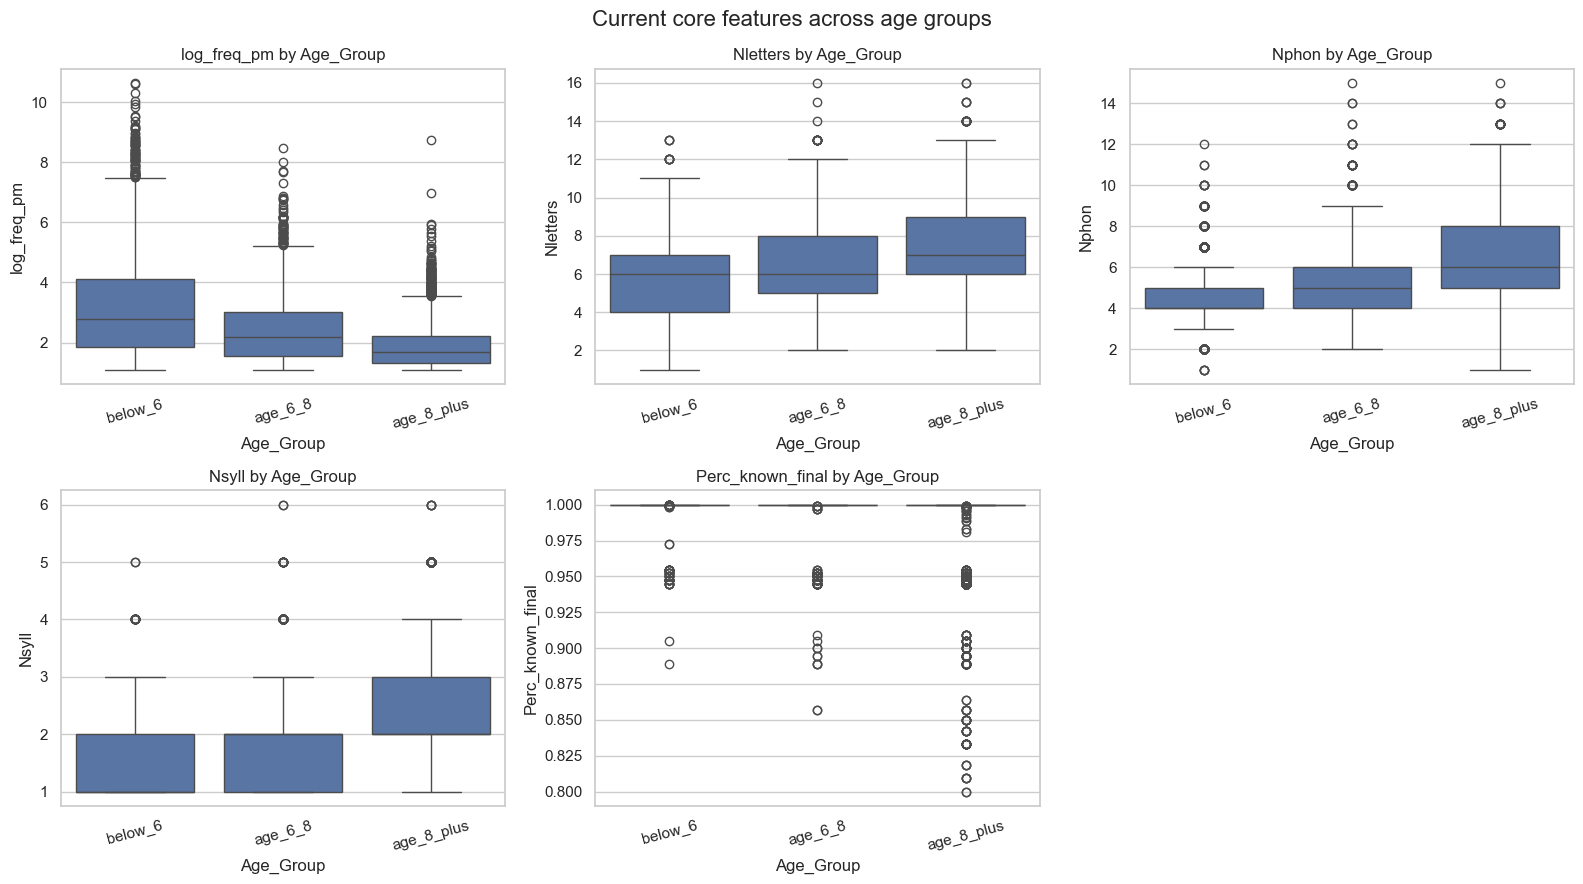

In [37]:
plot_cols = ['log_freq_pm', 'Nletters', 'Nphon', 'Nsyll', 'Perc_known_final']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols):
    sns.boxplot(data=df, x='Age_Group', y=col, order=['below_6', 'age_6_8', 'age_8_plus'], ax=ax)
    ax.set_title(f'{col} by Age_Group')
    ax.set_xlabel('Age_Group')
    ax.tick_params(axis='x', rotation=15)

axes[-1].axis('off')
fig.suptitle('Current core features across age groups', fontsize=16)
plt.tight_layout()
plt.show()


### Visual comparison of candidate engineered features

These plots show why the new ratio, interaction, and lemma-related features are worth testing. We want features that make the transition from early to later-acquired words easier to see.

下面这组图展示的是：为什么比例特征、交互特征和 lemma 相关特征值得加入。理想情况下，这些特征应该能更清楚地反映词从“更早习得”到“更晚习得”的变化趋势。


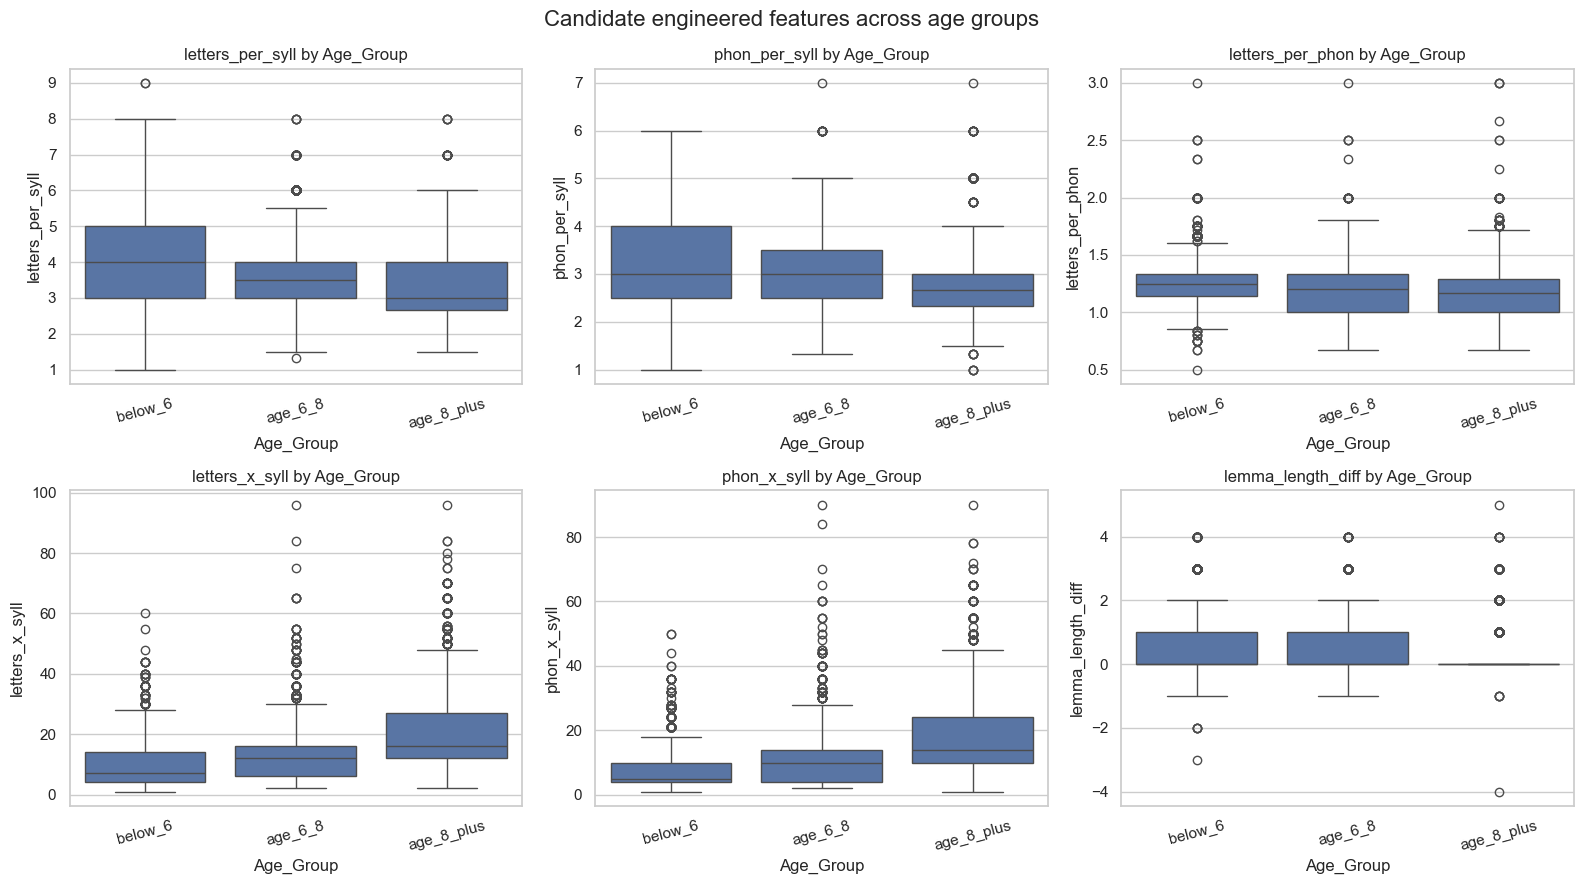

In [38]:
candidate_plot_cols = ['letters_per_syll', 'phon_per_syll', 'letters_per_phon', 'letters_x_syll', 'phon_x_syll', 'lemma_length_diff']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, candidate_plot_cols):
    sns.boxplot(data=candidate_feature_df, x='Age_Group', y=col, order=['below_6', 'age_6_8', 'age_8_plus'], ax=ax)
    ax.set_title(f'{col} by Age_Group')
    ax.set_xlabel('Age_Group')
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('Candidate engineered features across age groups', fontsize=16)
plt.tight_layout()
plt.show()


### Feature trends against continuous AoA

Age groups are useful, but AoA is originally a continuous variable. Plotting candidate features directly against `AoA_final` helps show whether a feature changes smoothly with difficulty instead of only matching one hard boundary.

年龄组标签很有用，但 AoA 原本是连续变量。把候选特征直接和 `AoA_final` 画在一起，可以帮助我们判断：这个特征是不是随着词难度连续变化，而不只是碰巧适合某个分类边界。


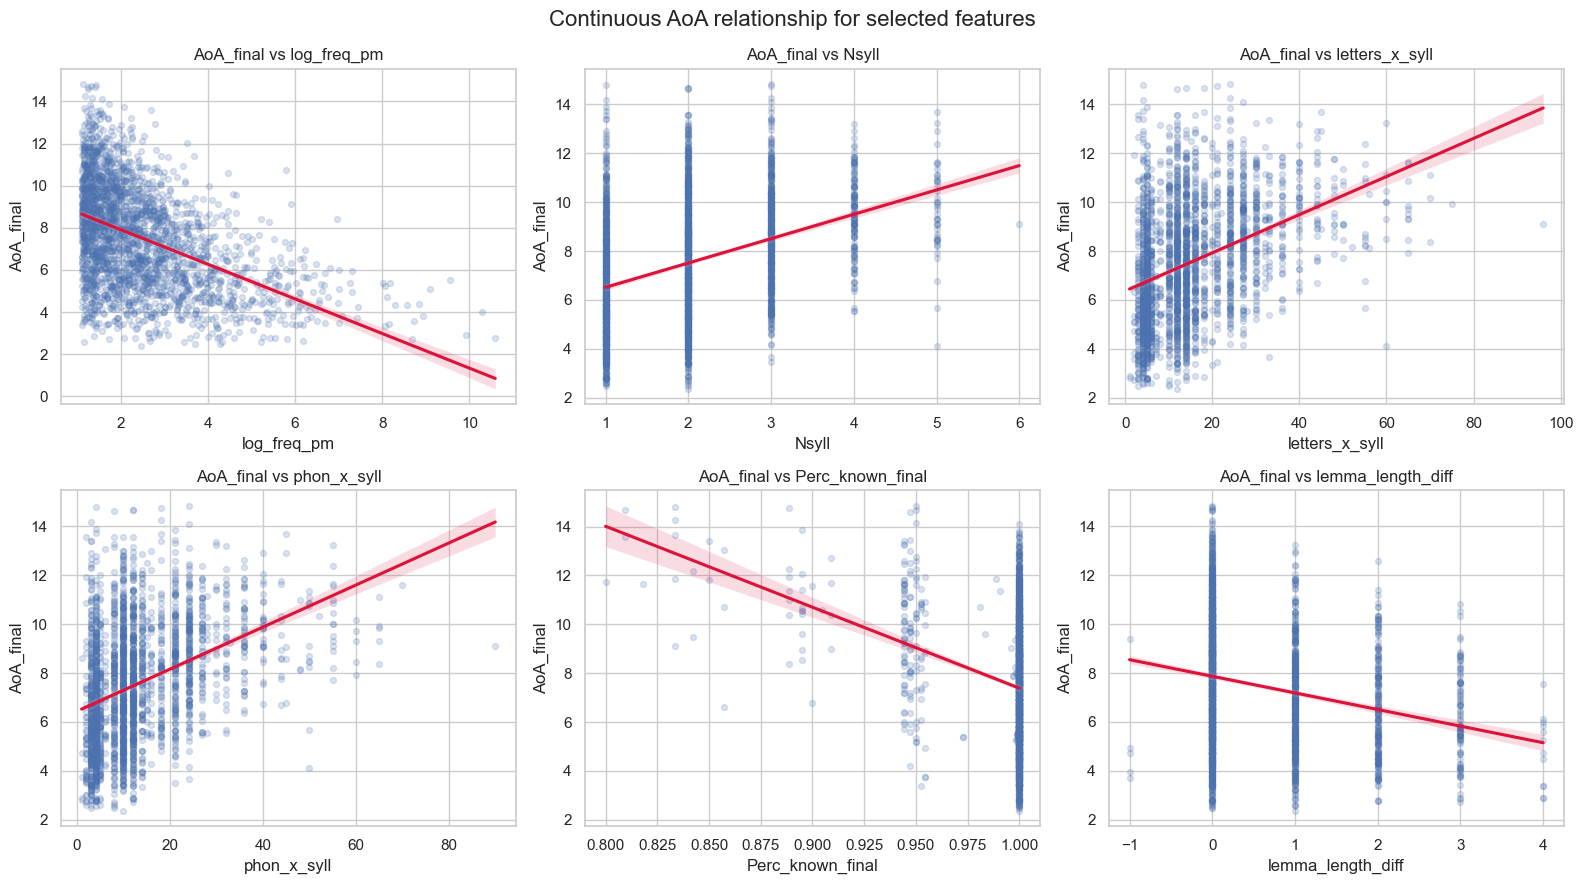

In [39]:
trend_cols = ['log_freq_pm', 'Nsyll', 'letters_x_syll', 'phon_x_syll', 'Perc_known_final', 'lemma_length_diff']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

sample_df = candidate_feature_df.sample(min(len(candidate_feature_df), 2500), random_state=42)

for ax, col in zip(axes, trend_cols):
    sns.regplot(data=sample_df, x=col, y='AoA_final', scatter_kws={'alpha': 0.2, 's': 18}, line_kws={'color': 'crimson'}, ax=ax)
    ax.set_title(f'AoA_final vs {col}')

fig.suptitle('Continuous AoA relationship for selected features', fontsize=16)
plt.tight_layout()
plt.show()


### Boundary-focused view

Because the `6-8` range is the hardest part, the next plots zoom in on words near the `6`-year and `8`-year thresholds. This makes it easier to see which engineered features might help the model separate the middle band.

由于 `6-8` 这一段最容易混淆，下面这组图专门放大 `6` 岁和 `8` 岁边界附近的样本。这样更容易看出：哪些 engineered features 可能帮助模型把中间年龄段分得更清楚。


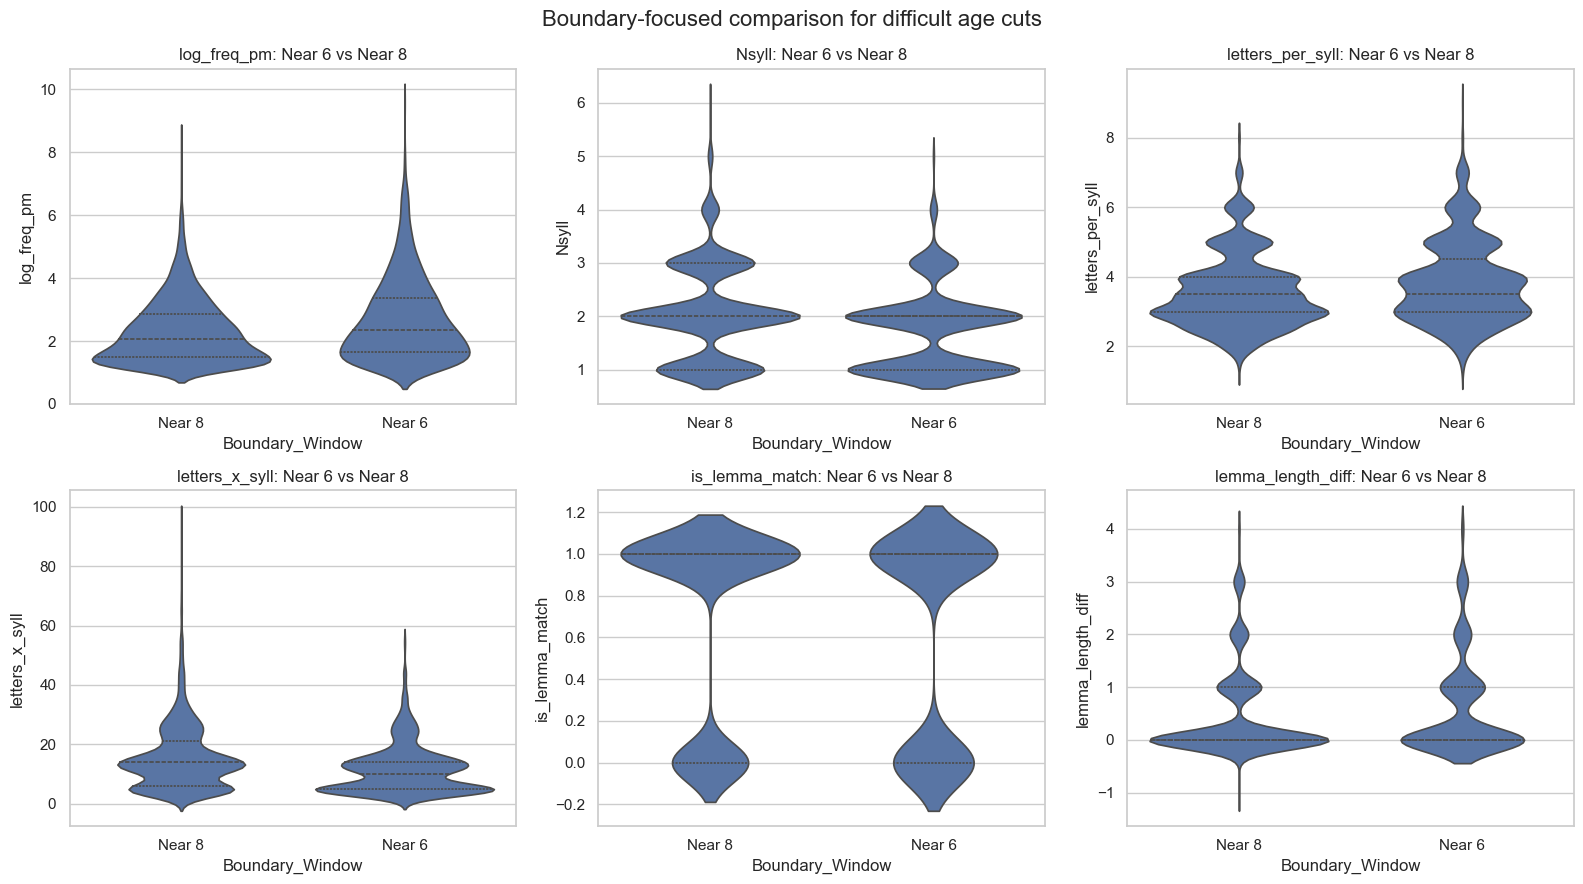

In [40]:
boundary_df = candidate_feature_df[candidate_feature_df['AoA_final'].between(5.5, 8.5)].copy()
boundary_df['Boundary_Window'] = np.where(boundary_df['AoA_final'] < 6.5, 'Near 6', 'Near 8')

boundary_plot_cols = ['log_freq_pm', 'Nsyll', 'letters_per_syll', 'letters_x_syll', 'is_lemma_match', 'lemma_length_diff']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, boundary_plot_cols):
    sns.violinplot(data=boundary_df, x='Boundary_Window', y=col, inner='quartile', ax=ax)
    ax.set_title(f'{col}: Near 6 vs Near 8')

fig.suptitle('Boundary-focused comparison for difficult age cuts', fontsize=16)
plt.tight_layout()
plt.show()


### What stands out

- `letters_x_syll` and `phon_x_syll` are stronger than many simple difference features, so interaction terms are worth trying.
- `Perc_known_final` is not as strong as frequency, but it still carries useful signal and should be included.
- `is_lemma_match` and `lemma_length_diff` add morphology-related information beyond raw length.
- `has_alt_spelling` looks weak in this dataset, so it should be treated as optional rather than a priority feature.
- `Dom_PoS_SUBTLEX` is usable, but it needs cleanup because some rows contain numeric noise. A grouped feature such as `pos_group` may be more stable.

这一轮分析里比较突出的点：
- `letters_x_syll` 和 `phon_x_syll` 比很多简单差值特征更强，说明交互特征值得尝试。
- `Perc_known_final` 虽然不如频率强，但仍然有用，应该纳入候选特征。
- `is_lemma_match` 和 `lemma_length_diff` 能提供长度之外的词形学信息。
- `has_alt_spelling` 在这个数据集里信号比较弱，更适合作为可选特征，而不是高优先级特征。
- `Dom_PoS_SUBTLEX` 可以使用，但要先清洗少量数值脏值；像 `pos_group` 这样的分组特征会更稳一些。


In [41]:
boundary_summaries = {}
for lower, upper, label in [(5.5, 6.5, 'near_6_boundary'), (7.5, 8.5, 'near_8_boundary')]:
    temp = candidate_feature_df[candidate_feature_df['AoA_final'].between(lower, upper)]
    boundary_summaries[label] = temp[[
        'log_freq_pm',
        'Nletters',
        'Nphon',
        'Nsyll',
        'Perc_known_final',
        'letters_per_syll',
        'phon_per_syll',
        'letters_per_phon',
        'is_lemma_match',
        'lemma_length_diff',
    ]].mean().round(3)

boundary_summary_df = pd.DataFrame(boundary_summaries)
display(boundary_summary_df)


,near_6_boundary,near_8_boundary
log_freq_pm,2.677,2.167
Nletters,6.150,6.994
Nphon,5.040,5.884
Nsyll,1.747,2.177
Perc_known_final,0.999,0.997
letters_per_syll,3.849,3.497
phon_per_syll,3.126,2.904
letters_per_phon,1.244,1.215
is_lemma_match,0.613,0.719
lemma_length_diff,0.607,0.432


### Boundary reading

The `6` and `8` year thresholds are naturally noisy because they slice a continuous AoA value into classes. The boundary summary still helps show what the model may need to separate better:
- words near the `8` boundary are usually longer, lower-frequency, and more multi-syllabic than words near the `6` boundary
- words near the `6` boundary tend to have slightly higher `letters_per_syll` and slightly larger lemma-length differences
- this supports adding ratio features and lemma-related features instead of only adding more raw length columns

`6` 岁和 `8` 岁这两个阈值本身就比较容易产生边界噪声，因为它们把连续的 AoA 数值硬切成了分类标签。不过边界统计仍然能帮助我们理解模型还缺什么信息：
- 靠近 `8` 岁边界的词通常更长、频率更低、而且音节更多
- 靠近 `6` 岁边界的词通常 `letters_per_syll` 稍高，而且 lemma 长度差也略大
- 这说明下一步比起继续只加原始长度列，更值得加入比例特征和 lemma 相关特征


## 5. Recommended next feature sets

Based on the current file analysis, the best next step is to expand the baseline feature set in stages.

Recommended `FeatureSet-A`:
1. `log_freq_pm`
2. `Nletters`
3. `Nphon`
4. `Nsyll`
5. `Perc_known_final`
6. `letters_per_syll`
7. `phon_per_syll`
8. `letters_per_phon`
9. `letters_x_syll`
10. `phon_x_syll`
11. `is_lemma_match`
12. `lemma_length_diff`

Recommended `FeatureSet-B` for a second experiment:
1. all features in `FeatureSet-A`
2. `Dom_PoS_SUBTLEX` or `pos_group`
3. `AoA_source`

Features to avoid as direct predictors for now:
- `AoA_Kup`, `AoA_Kup_lem`, `AoA_Bird_lem`, `AoA_Bristol_lem`, `AoA_Cort_lem`, `AoA_Schock`
  These are source AoA labels and can leak target information into the model.

基于当前文件分析，下一步最合理的做法是分阶段扩展 baseline 特征集。

推荐的 `FeatureSet-A`：
1. `log_freq_pm`
2. `Nletters`
3. `Nphon`
4. `Nsyll`
5. `Perc_known_final`
6. `letters_per_syll`
7. `phon_per_syll`
8. `letters_per_phon`
9. `letters_x_syll`
10. `phon_x_syll`
11. `is_lemma_match`
12. `lemma_length_diff`

第二轮实验建议的 `FeatureSet-B`：
1. 包含 `FeatureSet-A` 的所有特征
2. `Dom_PoS_SUBTLEX` 或 `pos_group`
3. `AoA_source`

当前不建议直接作为预测特征使用的列：
- `AoA_Kup`, `AoA_Kup_lem`, `AoA_Bird_lem`, `AoA_Bristol_lem`, `AoA_Cort_lem`, `AoA_Schock`
  这些列本身就是 AoA 标签来源，直接进模型容易造成目标信息泄漏。


In [42]:
selected_features = [
    'log_freq_pm',
    'Nletters',
    'Nphon',
    'Nsyll',
    'Perc_known_final',
    'letters_per_syll',
    'phon_per_syll',
    'letters_per_phon',
    'letters_x_syll',
    'phon_x_syll',
    'is_lemma_match',
    'lemma_length_diff',
]

feature_set_a_df = candidate_feature_df[selected_features + ['AoA_final', 'Age_Group', 'Word']].copy()
display(feature_set_a_df.head())
print('FeatureSet-A shape:', feature_set_a_df.shape)


,log_freq_pm,Nletters,Nphon,Nsyll,Perc_known_final,letters_per_syll,phon_per_syll,letters_per_phon,letters_x_syll,phon_x_syll,is_lemma_match,lemma_length_diff,AoA_final,Age_Group,Word
0,9.924088,1,1,1,1.000000,1.000000,1.000000,1.000000,1,1,1,0,2.893384,below_6,a
1,2.208059,7,7,3,1.000000,2.333333,2.333333,1.000000,21,21,1,0,8.320000,age_8_plus,abandon
2,2.659848,9,8,3,1.000000,3.000000,2.666667,1.125000,27,24,0,2,8.320000,age_8_plus,abandoned
3,1.429467,5,3,2,0.857143,2.500000,1.500000,1.666667,10,6,1,0,13.060000,age_8_plus,abbey
4,1.470852,7,7,3,1.000000,2.333333,2.333333,1.000000,21,21,1,0,8.610000,age_8_plus,abdomen


FeatureSet-A shape: (9997, 15)


## 6. Next step

A practical next step is now clear:
- first build a dedicated feature engineering notebook to create `FeatureSet-A` and `FeatureSet-B`
- then compare a baseline classifier, a regression-then-bucket approach, and an ordinal-friendly model

Use stratified validation for `Age_Group`, and one-hot encode categorical features only after cleaning them.

现在下一步已经比较清晰了：
- 先新建一个专门的 feature engineering notebook，正式构造 `FeatureSet-A` 和 `FeatureSet-B`
- 然后再比较 baseline classifier、regression-then-bucket，以及更适合有序标签的模型

对于 `Age_Group`，建议使用 stratified validation；对类别特征，也要在清洗完成之后再做 one-hot encoding。
